# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import plotly.express as ex

# Reading the Data

In [ ]:
df = pd.read_csv("/content/spam.csv", encoding = "ISO-8859-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# EDA

In [ ]:
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns')

There are 5572 rows and 5 columns


In [ ]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

### There are some attributes have a considerable number of NULL values (~5.5k) so dropping wouldn't be a problem.

In [ ]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [ ]:
# Rename the columns to 'Category' and 'Message'

df.rename(columns={'v1': 'Category', 'v2': 'Message'}, inplace=True)

df.columns

Index(['Category', 'Message'], dtype='object')

In [ ]:
df.describe().T

,count,unique,top,freq
Category,5572,2,ham,4825
Message,5572,5169,"Sorry, I'll call later",30


In [ ]:
df['Category'].value_counts()

ham     4825
spam     747
Name: Category, dtype: int64

## Managing duplicate entries

In [ ]:
df.duplicated().sum()

403

In [ ]:
df.drop_duplicates(inplace = True)

df.duplicated().sum()

0

# Data Visualization

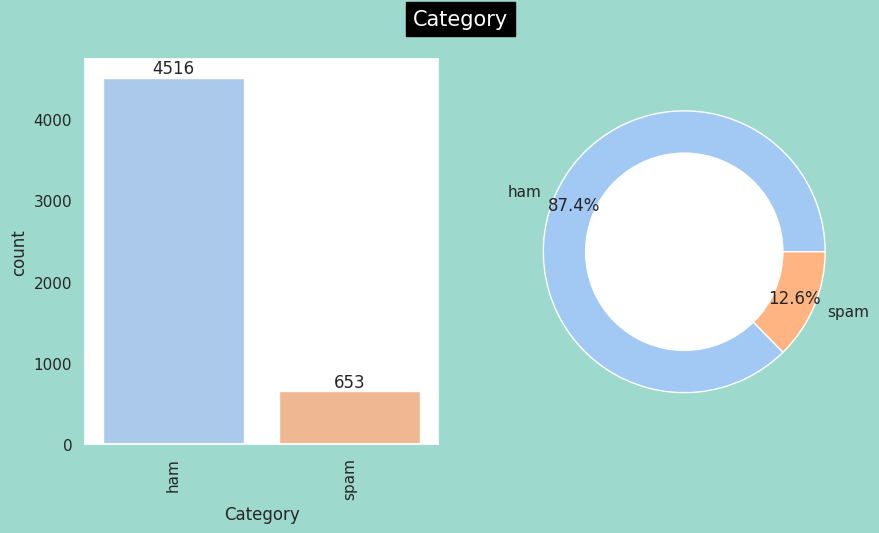

In [ ]:
sns.set(rc={"axes.facecolor":"white","figure.facecolor":"#9ed9cd"})
sns.set_palette("pastel")


fig, axes = plt.subplots(1,2,figsize=(10,5))

# count of col (countplot)

ax=sns.countplot(data=df, x="Category", ax=axes[0])
activities = [var for var in df["Category"].value_counts().sort_index().index]
ax.set_xticklabels(activities,rotation=90)
for container in axes[0].containers:
    axes[0].bar_label(container)

#count of col (pie chart)

index = df["Category"].value_counts().index
size = df["Category"].value_counts().values
explode = (0.05, 0.05)

axes[1].pie(size, labels=index,autopct='%1.1f%%', pctdistance=0.85)

# Inner circle
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.suptitle("Category",backgroundcolor='black',color='white',fontsize=15)

plt.show()

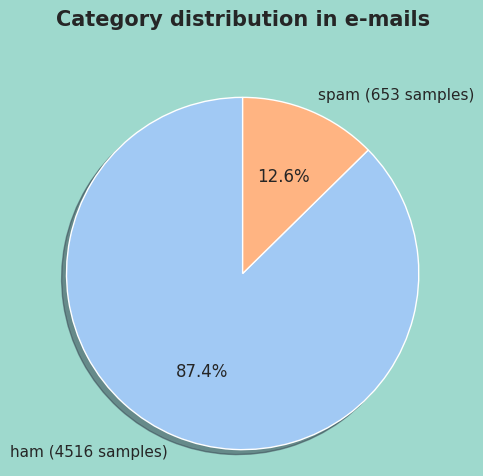

In [ ]:
labels = [f'{k} ({df["Category"].value_counts()[k]} samples)' for k in df['Category'].value_counts().keys()]
sizes = dict(df['Category'].value_counts()).values()

fig1, ax1 = plt.subplots(figsize=(5,5))
ax1.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
ax1.set_title("Category distribution in e-mails",pad=40, fontweight='bold', fontsize=15)
plt.show()

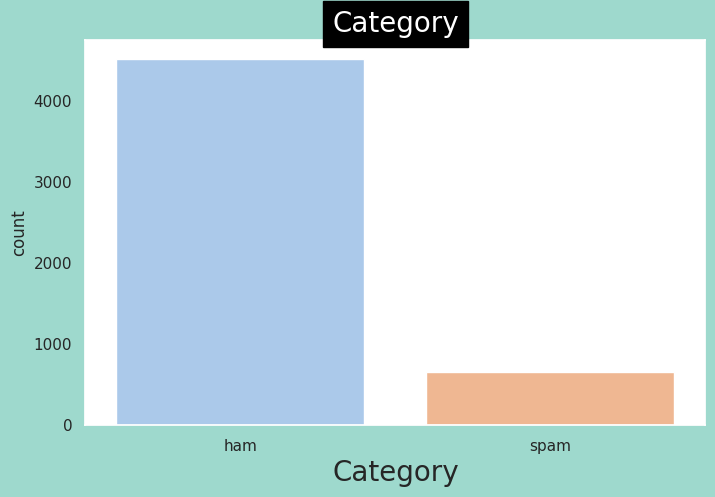

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x=df['Category'], data=df)
plt.title('Category',backgroundcolor='black',color='white',fontsize=20)
plt.xlabel('Category',fontsize=20)
plt.grid()
plt.show()

## Transform the target variable into its numeric representation

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5169 non-null   object
 1   Message   5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [ ]:
df.nunique()

Category       2
Message     5169
dtype: int64

In [ ]:
df.loc[df["Category"] == "spam" ,"Category"] = 0
df.loc[df["Category"] == "ham" ,"Category"] = 1

df["Category"] = df["Category"].astype("int")

df.tail()

,Category,Message
5567,0,This is the 2nd time we have tried 2 contact u...
5568,1,Will Ì_ b going to esplanade fr home?
5569,1,"Pity, * was in mood for that. So...any other s..."
5570,1,The guy did some bitching but I acted like i'd...
5571,1,Rofl. Its true to its name


In [ ]:
df.dtypes

Category     int64
Message     object
dtype: object

In [ ]:
pie_fig = ex.pie(df, names=df['Category'], title=f'Category Occurrence', color_discrete_sequence=ex.colors.sequential.Aggrnyl)
pie_fig.update_traces(textposition='inside', textinfo='percent+label')
pie_fig.update_layout(showlegend=False)
pie_fig.show()

# Show the plot
plt.show()

# Split the data into Target and Feature columns

In [ ]:
X = df["Message"].values
y = df["Category"].values

# Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

feature_extraction = TfidfVectorizer(min_df = 1,stop_words = "english")

X = feature_extraction.fit_transform(X)

# Classification Models with 10-Fold Cross Validation

### Why 10 is the best number of folds?

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

overall_accuracy = []

for i in range (2, 11):
  kf = KFold(n_splits = i, shuffle = True, random_state=42)

  accuracy_scores = []

  for train_index, val_index in kf.split(X):
      X_train, X_val = X[train_index], X[val_index]
      y_train, y_val = y[train_index], y[val_index]

      model = RandomForestClassifier(n_estimators = 10, random_state = 0)
      model.fit(X_train, y_train)

      y_pred = model.predict(X_val)

      accuracy = accuracy_score(y_val, y_pred)
      accuracy_scores.append(accuracy*100)

  overall_accuracy.append(np.mean(accuracy_scores))

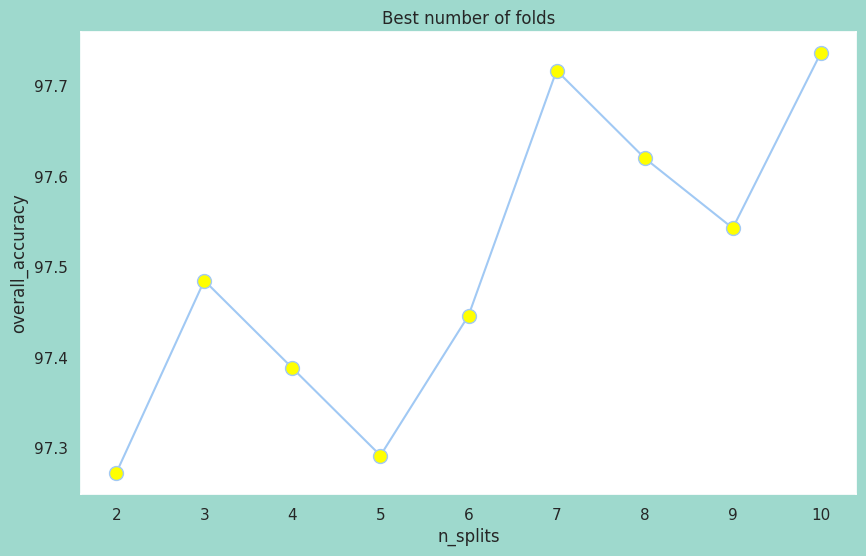

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(2, 11), overall_accuracy, marker = 'o', markerfacecolor='yellow', markersize = 10)
plt.title('Best number of folds')
plt.xlabel('n_splits')
plt.ylabel('overall_accuracy')
plt.show()

In [ ]:
max_acc = np.max(overall_accuracy)
indx = overall_accuracy.index(max_acc)
my_range = range(2, 11)
num_splits = my_range[indx]
print(f" {num_splits} is the best number of folds")

 10 is the best number of folds


## SVC

In [ ]:
from sklearn.svm import SVC

kf = KFold(n_splits = num_splits, shuffle = True, random_state=42)


accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = SVC(random_state=35)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores.append(accuracy)

for i, accuracy in enumerate(accuracy_scores):
    print(f"Fold {i+1} accuracy: {accuracy*100}")

print(f"\n\nOverall accuracy: {np.mean(accuracy_scores)*100}")

Fold 1 accuracy: 97.09864603481626
Fold 2 accuracy: 97.09864603481626
Fold 3 accuracy: 96.71179883945842
Fold 4 accuracy: 96.90522243713733
Fold 5 accuracy: 97.48549323017409
Fold 6 accuracy: 96.71179883945842
Fold 7 accuracy: 97.87234042553192
Fold 8 accuracy: 96.71179883945842
Fold 9 accuracy: 96.32495164410058
Fold 10 accuracy: 97.28682170542635


Overall accuracy: 97.0207518030378


## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_val)
    error_rate.append(np.mean(pred_i != y_val))

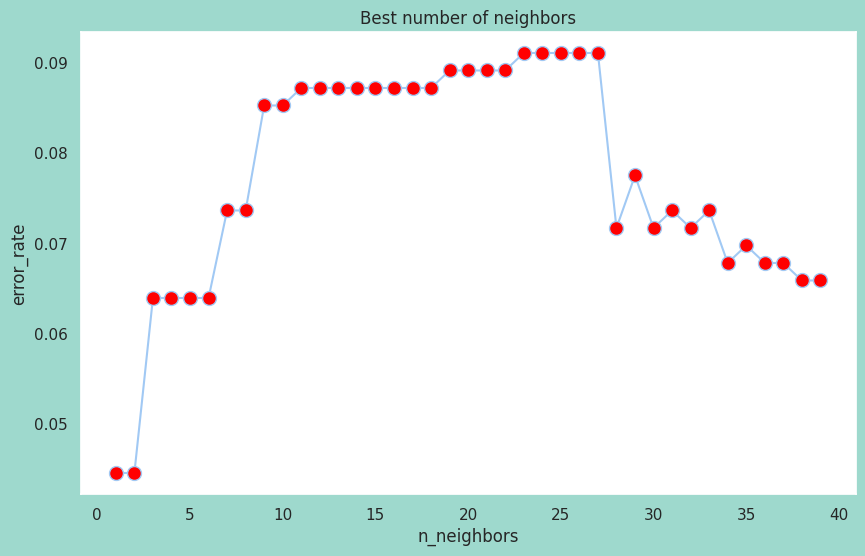

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(1,40), error_rate, marker = 'o', markerfacecolor='red', markersize = 10)
plt.title('Best number of neighbors')
plt.xlabel('n_neighbors')
plt.ylabel('error_rate')
plt.show()

In [ ]:
min_error = np.min(error_rate)
indx = error_rate.index(min_error)
my_range = range(1,40)
nn = my_range[indx]
print(f" {nn} is the best number of neighbors")

 1 is the best number of neighbors


In [ ]:
accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = KNeighborsClassifier(n_neighbors = nn)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores.append(accuracy)

for i, accuracy in enumerate(accuracy_scores):
    print(f"Fold {i+1} accuracy: {accuracy*100}")

print(f"\n\nOverall accuracy: {np.mean(accuracy_scores)*100}")

Fold 1 accuracy: 94.00386847195358
Fold 2 accuracy: 92.26305609284333
Fold 3 accuracy: 92.64990328820116
Fold 4 accuracy: 94.58413926499033
Fold 5 accuracy: 94.00386847195358
Fold 6 accuracy: 94.1972920696325
Fold 7 accuracy: 95.16441005802709
Fold 8 accuracy: 92.84332688588007
Fold 9 accuracy: 94.00386847195358
Fold 10 accuracy: 95.54263565891473


Overall accuracy: 93.92563687343498


## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

error_rate= []
for i in range(1, 40):
    dt = DecisionTreeClassifier(max_depth=i, random_state = 2)
    dt.fit(X_train, y_train)
    pred_i = dt.predict(X_val)
    error_rate.append(np.mean(pred_i != y_val))

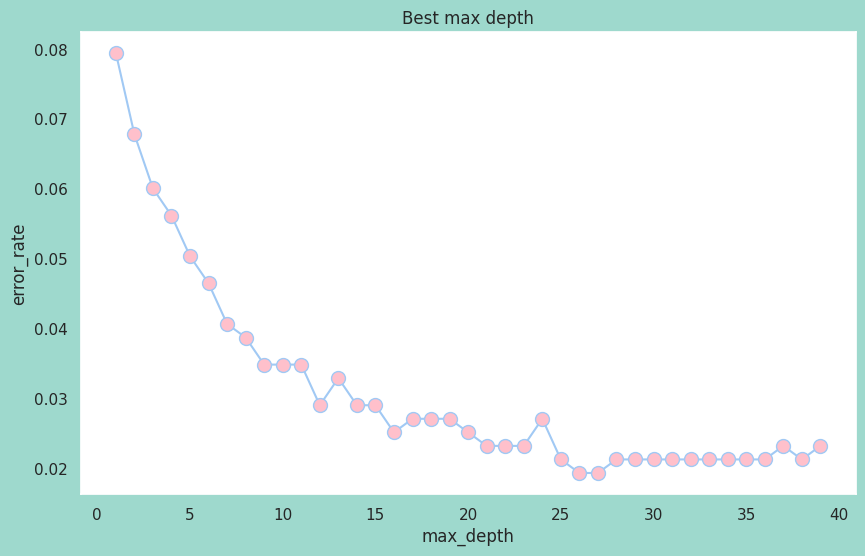

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(1, 40), error_rate, marker = 'o', markerfacecolor='pink', markersize = 10)
plt.title('Best max depth')
plt.xlabel('max_depth')
plt.ylabel('error_rate')
plt.show()

In [ ]:
min_error = np.min(error_rate)
indx = error_rate.index(min_error)
my_range = range(1, 40)
md = my_range[indx]
print(f" {md} is the best max depth")

 26 is the best max depth


In [ ]:
accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = DecisionTreeClassifier(max_depth=md, random_state = 2)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores.append(accuracy)

for i, accuracy in enumerate(accuracy_scores):
    print(f"Fold {i+1} accuracy: {accuracy*100}")

print(f"\n\nOverall accuracy: {np.mean(accuracy_scores)*100}")

Fold 1 accuracy: 95.74468085106383
Fold 2 accuracy: 96.5183752417795
Fold 3 accuracy: 96.32495164410058
Fold 4 accuracy: 96.90522243713733
Fold 5 accuracy: 95.93810444874275
Fold 6 accuracy: 96.32495164410058
Fold 7 accuracy: 97.87234042553192
Fold 8 accuracy: 96.71179883945842
Fold 9 accuracy: 95.16441005802709
Fold 10 accuracy: 98.06201550387597


Overall accuracy: 96.55668510938182


## Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = LogisticRegression(C=1000,max_iter=10000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores.append(accuracy)

for i, accuracy in enumerate(accuracy_scores):
    print(f"Fold {i+1} accuracy: {accuracy*100}")

print(f"\n\nOverall accuracy: {np.mean(accuracy_scores)*100}\n\n\n")

Fold 1 accuracy: 97.678916827853
Fold 2 accuracy: 97.29206963249516
Fold 3 accuracy: 97.48549323017409
Fold 4 accuracy: 97.48549323017409
Fold 5 accuracy: 98.45261121856866
Fold 6 accuracy: 98.64603481624758
Fold 7 accuracy: 98.45261121856866
Fold 8 accuracy: 97.48549323017409
Fold 9 accuracy: 97.09864603481626
Fold 10 accuracy: 98.06201550387597


Overall accuracy: 97.81393849429477





## Random Forest

In [ ]:
error_rate= []
for i in range(1, 40):
    rf = RandomForestClassifier(n_estimators =i, random_state = 0)
    rf.fit(X_train, y_train)
    pred_i = rf.predict(X_val)
    error_rate.append(np.mean(pred_i != y_val))

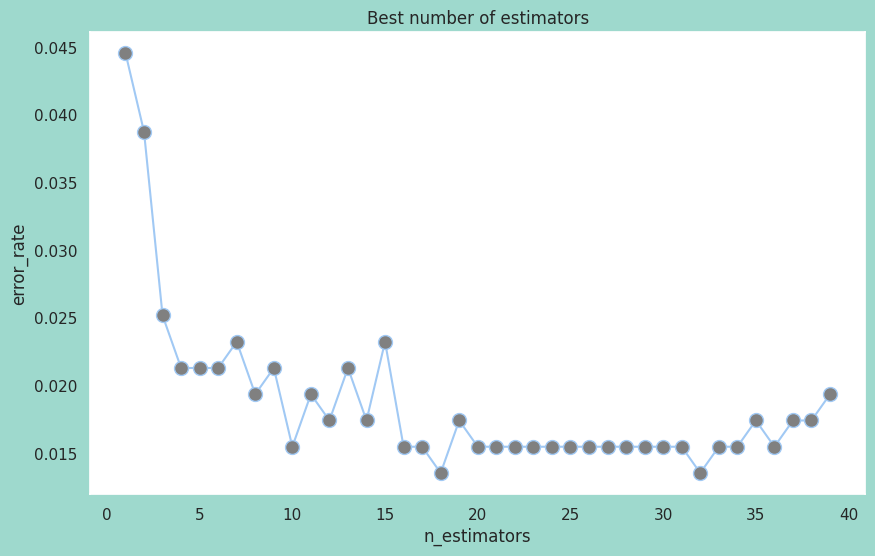

In [ ]:
plt.figure(figsize = (10,6))
plt.plot(range(1,40),error_rate,marker = 'o',markerfacecolor='gray',markersize = 10)
plt.title('Best number of estimators')
plt.xlabel('n_estimators')
plt.ylabel('error_rate')
plt.show()

In [ ]:
min_error = np.min(error_rate)
indx = error_rate.index(min_error)
my_range = range(1, 40)
ne = my_range[indx]
print(f" {ne} is the best number of estimators")

 18 is the best number of estimators


In [ ]:
accuracy_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    model = RandomForestClassifier(n_estimators = ne, random_state = 0)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    accuracy = accuracy_score(y_val, y_pred)
    accuracy_scores.append(accuracy)

for i, accuracy in enumerate(accuracy_scores):
    print(f"Fold {i+1} accuracy: {accuracy*100}")

print(f"\n\nOverall accuracy: {np.mean(accuracy_scores)*100}")

Fold 1 accuracy: 97.678916827853
Fold 2 accuracy: 97.48549323017409
Fold 3 accuracy: 96.90522243713733
Fold 4 accuracy: 97.29206963249516
Fold 5 accuracy: 98.06576402321083
Fold 6 accuracy: 97.87234042553192
Fold 7 accuracy: 98.64603481624758
Fold 8 accuracy: 97.48549323017409
Fold 9 accuracy: 97.678916827853
Fold 10 accuracy: 98.64341085271317


Overall accuracy: 97.77536623033902


# Gradient Boosting with "train_test_split" method

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.ensemble import  GradientBoostingClassifier

# Data Split [Features - Target]
x = df['Message']
y = df['Category']

In [ ]:
# Feature Extraction
x = feature_extraction.fit_transform(x)

# Split Data [Train - Test]
x_train , x_test , y_train , y_test = train_test_split(x, y, test_size = .20, random_state = 0)

In [ ]:
seed=0
gb_params ={
    'n_estimators': 1500,
    'learning_rate' : 0.25,
    'max_depth': 4,
    'min_samples_leaf': 2,
    'subsample': 1,
    'max_features' : 'sqrt',
    'random_state' : seed,
    'verbose': 1}


gb = GradientBoostingClassifier(**gb_params)
gb.fit(x_train , y_train)

      Iter       Train Loss   Remaining Time 
         1           0.7186           13.83s
         2           0.6838           10.45s
         3           0.6353            9.33s
         4           0.5776            8.84s
         5           0.5563            8.43s
         6           0.5469            8.19s
         7           0.5329            8.01s
         8           0.5155            7.87s
         9           0.5001            7.79s
        10           0.4876            7.69s
        20           0.3518            7.36s
        30           0.2713            7.25s
        40           0.2201            6.96s
        50           0.1920            6.80s
        60           0.1672            6.59s
        70           0.1442            6.55s
        80           0.1286            6.41s
        90           0.1127            6.28s
       100           0.1031            6.22s
       200           0.0456            5.76s
       300           0.0252            5.20s
       40

GradientBoostingClassifier(learning_rate=0.25, max_depth=4, max_features='sqrt',
                           min_samples_leaf=2, n_estimators=1500,
                           random_state=0, subsample=1, verbose=1)

In [ ]:
y_pred = gb.predict(x_test)
print(f"Accuracy: {accuracy_score(y_test,y_pred)*100}")

Accuracy: 97.96905222437138


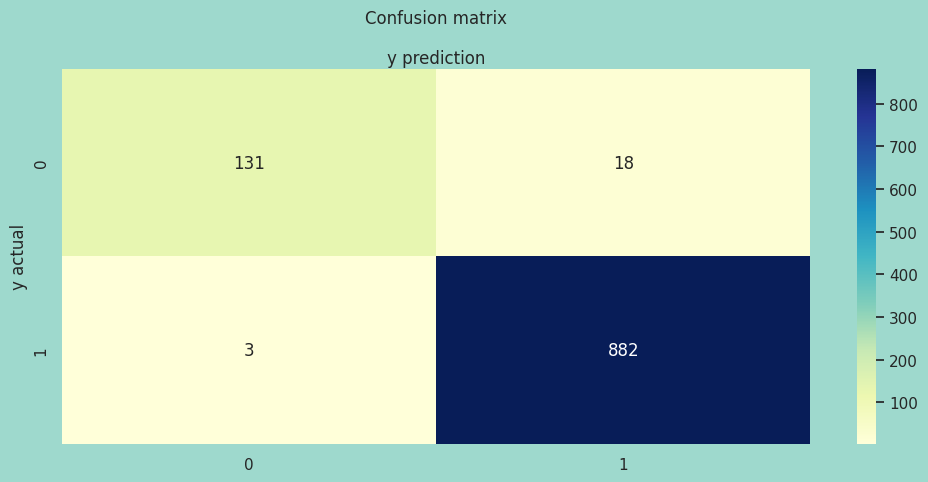

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm ,annot=True, cmap="YlGnBu" ,fmt='g')
plt.title('Confusion matrix', y=1.1)
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.xlabel('y prediction')
plt.ylabel('y actual')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93       149
           1       0.98      1.00      0.99       885

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



# Thank You